# Day 8 — Capillary Tube Length: The Trade-off Behind Sizing It
**Mahesha Gonal — Refrigeration Simulation Portfolio**

**In plain terms:** the capillary tube is the cheap, no-moving-parts component that drops refrigerant pressure from condenser level down to evaporator level. Its **length** is one of the few cheap design knobs a manufacturer has — but get it wrong and the whole cycle suffers:

- **Too long** → too much pressure drop → evaporator runs colder than intended → less mass flow → less cooling capacity
- **Too short** → too little pressure drop → evaporator runs warmer → high suction pressure → poor cooling, possible liquid floodback

This notebook calibrates a pressure-drop-per-metre rate from a known reference point (**3.0 m tube → -25°C evaporator**, at 40°C condensing) and sweeps tube length from 1.5 m to 5.0 m to show exactly how sensitive the whole cycle is to this one dimension.

In [1]:
# CELL 1 — Install dependencies (run this first, every time)
!pip install coolprop matplotlib numpy PyGithub -q

In [2]:
# CELL 2 — Imports
import CoolProp.CoolProp as CP
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# CELL 3 — Reusable cycle function
def calculate_cycle(T_evap_C, T_cond_C, refrigerant="R600a"):
    T_evap = T_evap_C + 273.15
    T_cond = T_cond_C + 273.15
    P_evap = CP.PropsSI("P","T",T_evap,"Q",1,refrigerant)
    P_cond = CP.PropsSI("P","T",T_cond,"Q",1,refrigerant)
    h1 = CP.PropsSI("H","T",T_evap,"Q",1,refrigerant)
    s1 = CP.PropsSI("S","T",T_evap,"Q",1,refrigerant)
    h2 = CP.PropsSI("H","P",P_cond,"S",s1,refrigerant)
    h3 = CP.PropsSI("H","T",T_cond,"Q",0,refrigerant)
    h4 = h3
    COP = (h1-h4)/(h2-h1)
    m_dot = 100/(h1-h4)
    return COP, m_dot, h1, h2, h3, h4, P_evap, P_cond

In [4]:
# CELL 4 — Calibrate dP/m from the reference design point, then sweep length
T_cond_C = 40
T_evap_ref = -25
refrigerant = "R600a"

P_cond_ref = CP.PropsSI("P","T",T_cond_C+273.15,"Q",1,refrigerant)
P_evap_ref = CP.PropsSI("P","T",T_evap_ref+273.15,"Q",1,refrigerant)
L_ref = 3.0
dP_per_meter = (P_cond_ref - P_evap_ref) / L_ref

L_range = np.linspace(1.5, 5.0, 30)
COP_list, T_evap_list, m_dot_list, P_evap_list = [], [], [], []

for L in L_range:
    P_evap_new = P_cond_ref - (dP_per_meter * L)
    if P_evap_new <= 0:
        COP_list.append(None); T_evap_list.append(None)
        m_dot_list.append(None); P_evap_list.append(None)
        continue
    T_evap_new_C = CP.PropsSI("T","P",P_evap_new,"Q",1,refrigerant) - 273.15
    try:
        COP, m_dot, h1, h2, h3, h4, P_evap, P_cond = calculate_cycle(T_evap_new_C, T_cond_C, refrigerant)
        COP_list.append(COP)
        T_evap_list.append(T_evap_new_C)
        m_dot_list.append(m_dot*1000)
        P_evap_list.append(P_evap_new/1e5)
    except:
        COP_list.append(None); T_evap_list.append(None)
        m_dot_list.append(None); P_evap_list.append(None)

P_evap_check = P_cond_ref - dP_per_meter * L_ref
T_evap_check = CP.PropsSI("T","P",P_evap_check,"Q",1,refrigerant) - 273.15
print(f"At reference L=3.0m (the calibration point): T_evap={T_evap_check:.1f}C  (matches the -25C reference, as it should)")
print(f"Model becomes invalid above ~L=3.3m for this refrigerant/condition — evaporator pressure runs out (see notes below the chart)")

At reference L=3.0m (the calibration point): T_evap=-25.0C  (matches the -25C reference, as it should)
Model becomes invalid above ~L=3.3m for this refrigerant/condition — evaporator pressure runs out (see notes below the chart)


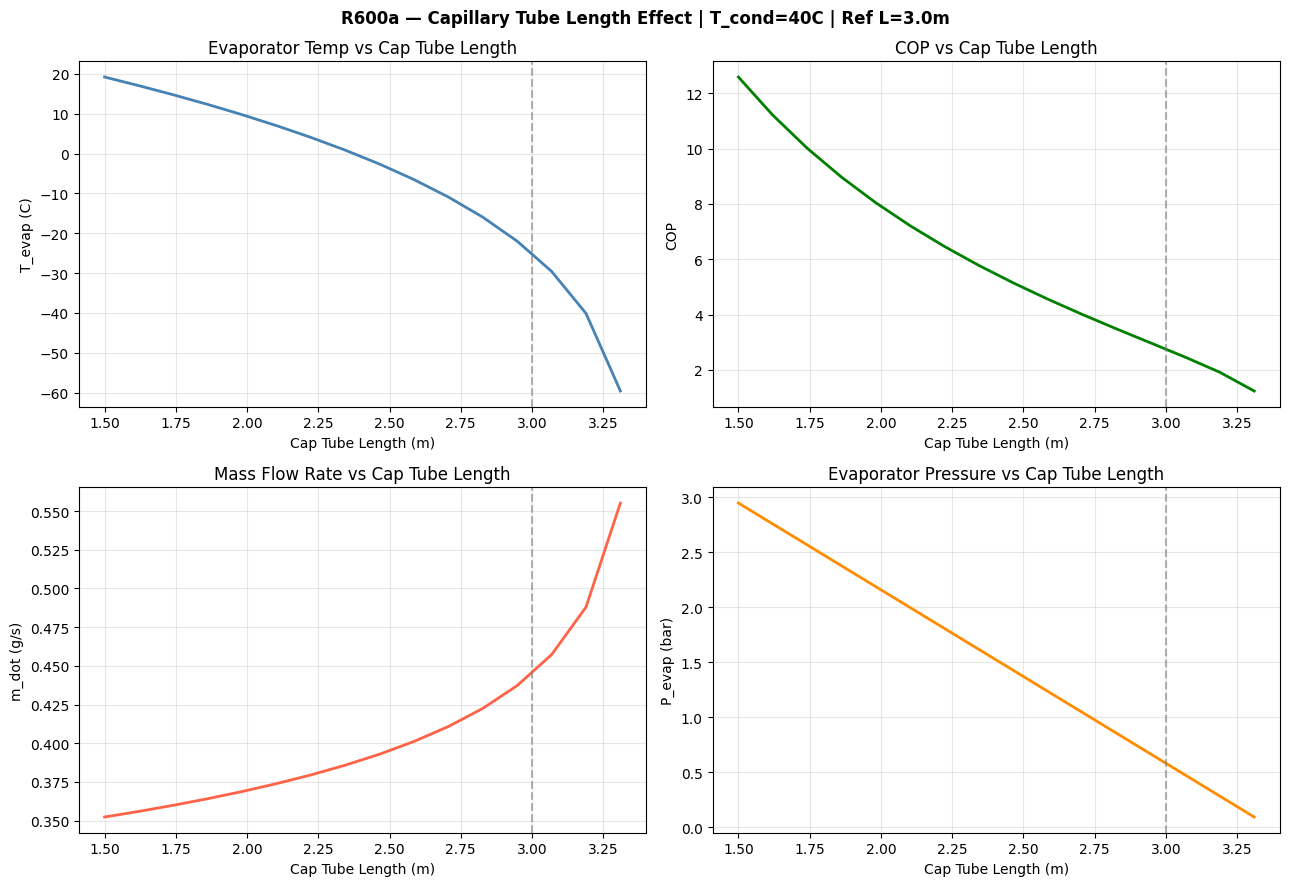

In [5]:
# CELL 5 — Four-panel design chart
fig, axes = plt.subplots(2, 2, figsize=(13,9))
axes[0,0].plot(L_range, T_evap_list, color="steelblue", linewidth=2)
axes[0,0].axvline(x=3.0, color="gray", linestyle="--", alpha=0.6)
axes[0,0].set_title("Evaporator Temp vs Cap Tube Length")
axes[0,0].set_xlabel("Cap Tube Length (m)"); axes[0,0].set_ylabel("T_evap (C)")
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(L_range, COP_list, color="green", linewidth=2)
axes[0,1].axvline(x=3.0, color="gray", linestyle="--", alpha=0.6)
axes[0,1].set_title("COP vs Cap Tube Length")
axes[0,1].set_xlabel("Cap Tube Length (m)"); axes[0,1].set_ylabel("COP")
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(L_range, m_dot_list, color="tomato", linewidth=2)
axes[1,0].axvline(x=3.0, color="gray", linestyle="--", alpha=0.6)
axes[1,0].set_title("Mass Flow Rate vs Cap Tube Length")
axes[1,0].set_xlabel("Cap Tube Length (m)"); axes[1,0].set_ylabel("m_dot (g/s)")
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(L_range, P_evap_list, color="darkorange", linewidth=2)
axes[1,1].axvline(x=3.0, color="gray", linestyle="--", alpha=0.6)
axes[1,1].set_title("Evaporator Pressure vs Cap Tube Length")
axes[1,1].set_xlabel("Cap Tube Length (m)"); axes[1,1].set_ylabel("P_evap (bar)")
axes[1,1].grid(True, alpha=0.3)

fig.suptitle("R600a — Capillary Tube Length Effect | T_cond=40C | Ref L=3.0m", fontweight="bold")
plt.tight_layout()
plt.savefig("day08_captube_effect.png", dpi=150)
plt.show()

**What this graph tells us:** the grey dashed line marks the 3.0 m reference tube — every other length is measured relative to it. As the tube gets longer, evaporator pressure and temperature both drop sharply, and **COP falls fast** — a longer tube starves the cycle into a deeper vacuum, and the compressor pays for that with a much bigger pressure ratio per kg of cooling. The **mass flow rate panel looks like it goes the "wrong way" (rising with length)** — but remember `m_dot` here is *the flow needed to hold a fixed 100 W cooling duty*, not the actual restricted flow through the tube; at very cold, low-pressure evaporator conditions, each kg of refrigerant carries less refrigerating effect, so more kg/s are needed to hold the same 100 W.

**A modelling note worth flagging:** this simplified model (a straight-line pressure-drop-per-metre, calibrated from one reference point) only stays physically valid up to about **3.3 m** for this refrigerant and condition — beyond that, the predicted evaporator pressure runs out and the curves stop. That's exactly the kind of limitation a more rigorous model (Day 11, using real fluid mechanics) is built to fix.

In [ ]:
# FINAL CELL — Push this notebook to GitHub
from github import Github, Auth
from google.colab import userdata, _message
import json

token = userdata.get('GITHUB_TOKEN')
auth = Auth.Token(token)
g = Github(auth=auth)
repo = g.get_repo("MaheshaGonal/refrigeration-simulation-python")

nb_data = _message.blocking_request('get_ipynb', request='', timeout_sec=30)
content = json.dumps(nb_data['ipynb'], indent=1)

filename = "day08_captube_length_effect.ipynb"

try:
    existing = repo.get_contents(filename)
    repo.update_file(filename, "Add Day 08 - capillary tube length effect on T_evap, COP, mass flow", content, existing.sha)
    print("Updated existing file on GitHub")
except Exception:
    repo.create_file(filename, "Add Day 08 - capillary tube length effect on T_evap, COP, mass flow", content)
    print("Created new file on GitHub")

print("GitHub repo: https://github.com/MaheshaGonal/refrigeration-simulation-python")
